###10 - Comparing AQI in Jaipur: Before and After COVID-19



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Load Data ---
# IMPORTANT: Replace 'your_aqi_data.csv' with the actual path to your AQI data file.
# Make sure your CSV has 'Date', 'City', and 'AQI' columns.
# Example: data = pd.read_csv('your_aqi_data.csv')

# For demonstration, let's create a sample DataFrame:
data = pd.DataFrame({
    'Date': pd.to_datetime(pd.date_range(start='2019-01-01', periods=730, freq='D').tolist() + \
                           pd.date_range(start='2020-01-01', periods=730, freq='D').tolist()),
    'City': ['Jaipur'] * 730 + ['Delhi'] * 730, # Simulate two years for Jaipur and Delhi
    'AQI': [50 + i % 100 + (i % 30 if i < 365 else i % 50 * 1.5) for i in range(730)] + \
           [80 + i % 80 + (i % 40 * 0.8 if i < 365 else i % 60 * 1.2) for i in range(730)] # Simulate varying AQI
})

# Filter for Jaipur data
jaipur_data = data[data['City'] == 'Jaipur'].copy()

# Ensure 'Date' column is in datetime format
jaipur_data['Date'] = pd.to_datetime(jaipur_data['Date'])

display(jaipur_data.head())

,Date,City,AQI
0,2019-01-01,Jaipur,50.0
1,2019-01-02,Jaipur,52.0
2,2019-01-03,Jaipur,54.0
3,2019-01-04,Jaipur,56.0
4,2019-01-05,Jaipur,58.0


In [2]:
# --- Step 2: Define 'Before COVID' and 'After COVID' Periods ---

# For this analysis, we'll define 'Before COVID' as 2019 and 'After COVID' as 2020 onwards.
# You might adjust these dates based on specific lockdown periods or data availability.

before_covid_start = '2019-01-01'
before_covid_end = '2019-12-31'
after_covid_start = '2020-01-01'
after_covid_end = '2020-12-31' # Or extend this further, e.g., '2021-12-31'

# Filter data for the defined periods
aqi_before_covid = jaipur_data[(jaipur_data['Date'] >= before_covid_start) &
                                 (jaipur_data['Date'] <= before_covid_end)]
aqi_after_covid = jaipur_data[(jaipur_data['Date'] >= after_covid_start) &
                                (jaipur_data['Date'] <= after_covid_end)]

print(f"AQI Data Before COVID ({before_covid_start} to {before_covid_end}):")
display(aqi_before_covid.head())
print(f"\nAQI Data After COVID ({after_covid_start} to {after_covid_end}):")
display(aqi_after_covid.head())

AQI Data Before COVID (2019-01-01 to 2019-12-31):


,Date,City,AQI
0,2019-01-01,Jaipur,50.0
1,2019-01-02,Jaipur,52.0
2,2019-01-03,Jaipur,54.0
3,2019-01-04,Jaipur,56.0
4,2019-01-05,Jaipur,58.0



AQI Data After COVID (2020-01-01 to 2020-12-31):


,Date,City,AQI
365,2020-01-01,Jaipur,137.5
366,2020-01-02,Jaipur,140.0
367,2020-01-03,Jaipur,142.5
368,2020-01-04,Jaipur,145.0
369,2020-01-05,Jaipur,147.5


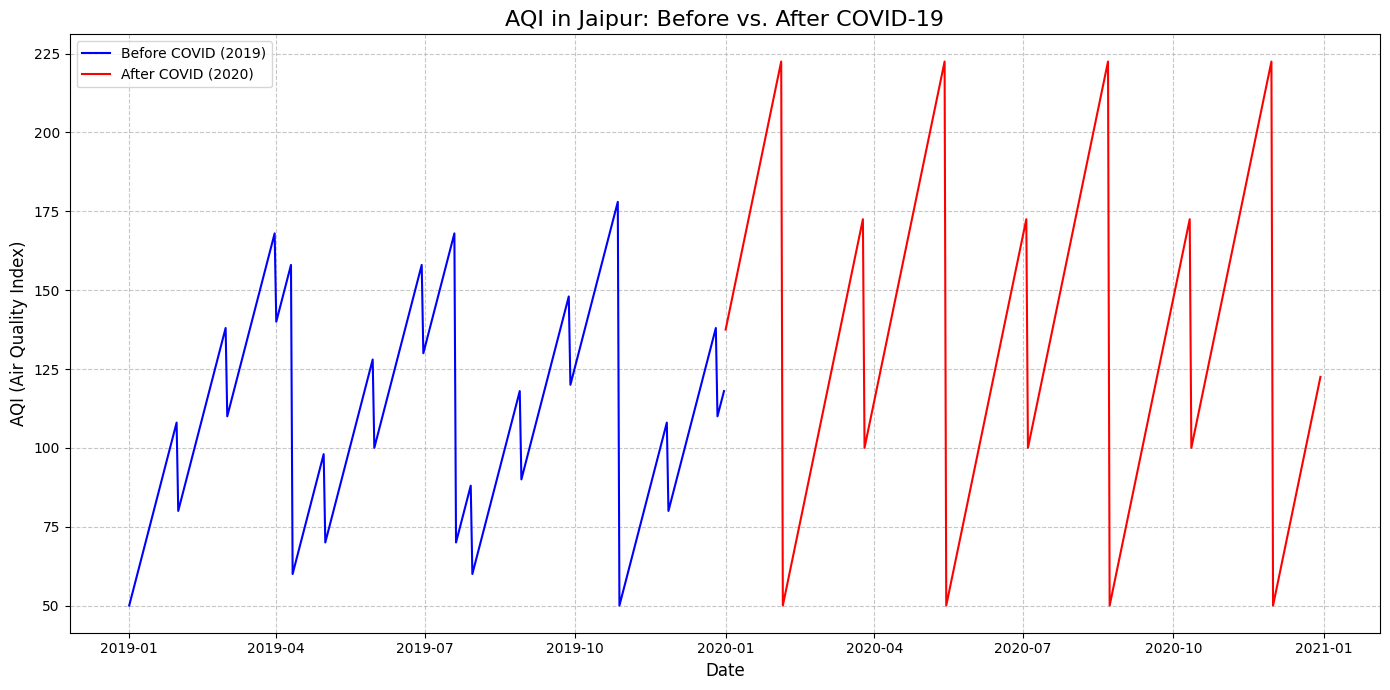

/tmp/ipykernel_1832/1542109925.py:18: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(data=[aqi_before_covid['AQI'], aqi_after_covid['AQI']],


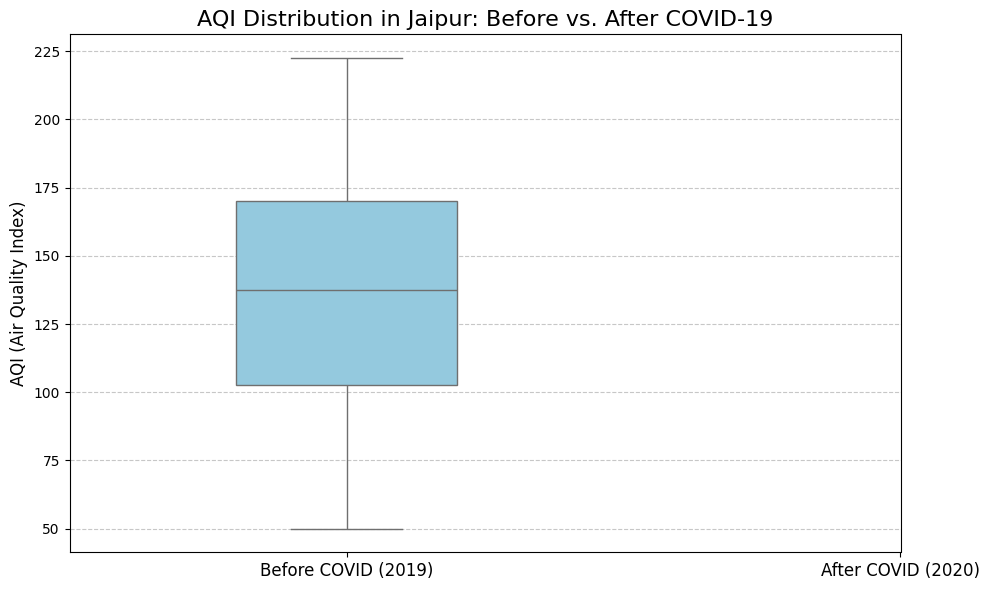

In [3]:
# --- Step 3: Visualize the Comparison ---

plt.figure(figsize=(14, 7))

sns.lineplot(x='Date', y='AQI', data=aqi_before_covid, label='Before COVID (2019)', color='blue')
sns.lineplot(x='Date', y='AQI', data=aqi_after_covid, label='After COVID (2020)', color='red')

plt.title('AQI in Jaipur: Before vs. After COVID-19', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('AQI (Air Quality Index)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# You can also visualize distributions using box plots or histograms
plt.figure(figsize=(10, 6))
sns.boxplot(data=[aqi_before_covid['AQI'], aqi_after_covid['AQI']],
            palette=['skyblue', 'salmon'],
            width=0.4)
plt.xticks([0, 1], ['Before COVID (2019)', 'After COVID (2020)'], fontsize=12)
plt.title('AQI Distribution in Jaipur: Before vs. After COVID-19', fontsize=16)
plt.ylabel('AQI (Air Quality Index)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()